## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



## Preliminary if Using Google Colab

- Recommended method: use `pip` with `requirements.txt` at the repository root.
- If you are in **Google Colab**, run the next code cell once to clone this repo and install dependencies.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/XinzeLee/Fundamentals_of_AI_for_PE/blob/main/7_Reinforcement_Learning/DDPG_buck_control.ipynb)


In [ ]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_dir = "/content/Fundamentals_of_AI_for_PE"
    if not os.path.isdir(repo_dir):
        !git clone https://github.com/XinzeLee/Fundamentals_of_AI_for_PE.git /content/Fundamentals_of_AI_for_PE
    %cd /content/Fundamentals_of_AI_for_PE
    !pip install -q -r requirements.txt
    os.chdir(os.path.join(repo_dir, "7_Reinforcement_Learning"))
else:
    print(
        "Not in Google Colab — skip clone/pip. Use your local env or run: pip install -r requirements.txt from the repo root."
    )


## DDPG-based voltage control of a buck converter (toy example)

**Authorship:** course materials — *Fundamentals of AI for PE*.

This notebook trains a **Deep Deterministic Policy Gradient (DDPG)** agent to command the **duty cycle** of an ideal **averaged** buck so that **output voltage** tracks a reference. Actions are **continuous**: the actor outputs a commanded **normalized action** in $[-1,1]$, scaled to a duty **increment** $\Delta D$ (same maximum slew magnitude as the discrete grid in the DQN tutorial). Only **NumPy** and **PyTorch** are required. A later section retrains with a **modified reward** that adds a moderate penalty on duty steps (smoother actuation) and compares waveforms to the baseline.

### Training (actor–critic with targets)
**Replay buffer**, **target actor** and **target critic**, and **soft (Polyak) updates** of the targets ($\theta' \leftarrow \tau\theta + (1-\tau)\theta'$) follow the usual DDPG recipe. Exploration uses **Ornstein–Uhlenbeck noise** on the action, with **$\sigma$ decaying** over training. The critic is trained with **Huber loss** on the **Bellman residual**; **TD targets** are **clipped** for stability; gradients are **clipped** on both networks. An in-memory **best actor checkpoint** (highest episodic return) is restored at the end.

### Plant model (continuous conduction, averaged)
State internal to the environment is $[i_L, v_{out}, D]^\top$. With duty $D \in [D_{min}, D_{max}]$ and input $V_{in}$:
- $\dot{i}_L = (D V_{in} - v) / L$
- $\dot{v} = (i_L - v/R) / C$

On each **reset**, **$V_{in}$** is sampled from a configurable range (so the policy sees **different input voltages**), together with random $v_{ref}$, $v_{out}(0)$, $i_L(0)$, and initial $D$.

> **Note:** Pedagogical surrogate — not a switching simulator. For hardware, add constraints, observers, and validation.


In [1]:
import math
import random
from collections import deque
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
class BuckAvgEnvContinuous:
    """Averaged buck: continuous u in [-1,1] -> delta D = u * delta_d_max; D clipped."""

    def __init__(
        self,
        Vin: float = 12.0,
        vin_range: Tuple[float, float] = (8.0, 24.0),
        L: float = 120e-6,
        C: float = 220e-6,
        R: float = 2.0,
        dt: float = 5e-6,
        d_min: float = 0.06,
        d_max: float = 0.92,
        max_episode_steps: int = 240,
        delta_d_max: float = 0.04,
    ):
        self.Vin_nom = float(Vin)
        self.vin_min, self.vin_max = float(vin_range[0]), float(vin_range[1])
        assert self.vin_min < self.vin_max
        self.L = L
        self.C = C
        self.R = R
        self.dt = dt
        self.d_min = d_min
        self.d_max = d_max
        self.max_episode_steps = max_episode_steps
        self.delta_d_max = float(delta_d_max)

        self.Vin = self.Vin_nom
        self._rescale_for_vin()
        self.step_count = 0
        self.state = None
        self.v_ref = 5.0

    def _rescale_for_vin(self):
        self.i_scale = self.Vin * self.d_max / max(self.R, 1e-6) * 1.5
        self.v_scale = max(self.Vin, 1e-6)

    def _observe(self):
        iL, v, D = self.state
        err = (v - self.v_ref) / self.v_scale
        d_n = (D - self.d_min) / max(self.d_max - self.d_min, 1e-6)
        return np.array(
            [
                err,
                iL / max(self.i_scale, 1e-6),
                float(d_n),
                self.v_ref / self.v_scale,
                self.Vin / self.vin_max,
            ],
            dtype=np.float32,
        )

    def reset(self, seed: Optional[int] = None):
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)
        self.Vin = float(np.random.uniform(self.vin_min, self.vin_max))
        self._rescale_for_vin()
        self.v_ref = float(np.random.uniform(0.22, 0.78) * self.Vin)
        v0 = float(np.random.uniform(0.03 * self.Vin, 0.97 * self.Vin))
        i0 = float(np.random.uniform(0.0, self.i_scale * 0.9))
        D0 = float(np.random.uniform(self.d_min, self.d_max))
        self.state = np.array([i0, v0, D0], dtype=np.float64)
        self.step_count = 0
        return self._observe(), {}

    def step(self, action: float):
        u = float(np.clip(action, -1.0, 1.0))
        iL, v, D_prev = self.state
        D = float(np.clip(D_prev + u * self.delta_d_max, self.d_min, self.d_max))

        di = (D * self.Vin - v) / self.L
        dv = (iL - v / self.R) / self.C
        noise = np.random.randn(2) * np.array(
            [self.i_scale * 2e-4, self.v_scale * 1e-4]
        )
        iL = iL + self.dt * di + noise[0]
        v = v + self.dt * dv + noise[1]
        iL = float(np.clip(iL, 0.0, self.i_scale))
        v = float(np.clip(v, 0.0, self.Vin))
        self.state = np.array([iL, v, D], dtype=np.float64)
        self.step_count += 1

        err = v - self.v_ref
        r_track = -float(err**2)
        r_i = -1e-4 * (iL / max(self.i_scale, 1e-6)) ** 2
        reward = float(np.clip(r_track + r_i, -50.0, 0.0))

        terminated = bool(v < 0.02 * self.v_ref or v > 1.08 * self.Vin)
        truncated = self.step_count >= self.max_episode_steps
        return self._observe(), reward, terminated, truncated, {}


env = BuckAvgEnvContinuous()
o0, _ = env.reset(seed=0)
print("obs dim:", o0.shape, "action: continuous in [-1,1]", "Vin range:", env.vin_min, "-", env.vin_max)


obs dim: (5,) action: continuous in [-1,1] Vin range: 8.0 - 24.0


In [3]:
from collections import deque
import copy
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim


class ReplayBufferDDPG:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, float(a), float(r), s2, float(done)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (
            torch.tensor(np.stack(s), device=device, dtype=torch.float32),
            torch.tensor(a, device=device, dtype=torch.float32).unsqueeze(1),
            torch.tensor(r, device=device, dtype=torch.float32).unsqueeze(1),
            torch.tensor(np.stack(s2), device=device, dtype=torch.float32),
            torch.tensor(d, device=device, dtype=torch.float32).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buf)


class OUNoise:
    # Ornstein-Uhlenbeck exploration noise (1-D action)

    def __init__(self, mu=0.0, theta=0.15, sigma=0.2):
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.state = np.array([self.mu], dtype=np.float32)

    def reset(self):
        self.state = np.array([self.mu], dtype=np.float32)

    def sample(self):
        x = self.state
        dx = self.theta * (self.mu - x) + self.sigma * np.random.randn(1).astype(np.float32)
        self.state = x + dx
        return float(self.state[0])


def linear_sigma(step: int, total: int, s0: float, s1: float) -> float:
    if total <= 1:
        return s1
    frac = min(1.0, step / float(total))
    return s0 + frac * (s1 - s0)


class Actor(nn.Module):
    # Deterministic policy: obs -> u in [-1, 1]

    def __init__(self, n_obs: int, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Tanh(),
        )
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.net(x)


class Critic(nn.Module):
    # Q(s, a), scalar action

    def __init__(self, n_obs: int, hidden: int = 256):
        super().__init__()
        self.q = nn.Sequential(
            nn.Linear(n_obs + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.apply(Actor._init)

    def forward(self, s, a):
        if a.dim() == 1:
            a = a.unsqueeze(1)
        x = torch.cat([s, a], dim=-1)
        return self.q(x)


def soft_update(target: nn.Module, source: nn.Module, tau: float):
    with torch.no_grad():
        for tp, sp in zip(target.parameters(), source.parameters()):
            tp.data.copy_(tau * sp.data + (1.0 - tau) * tp.data)


def train_ddpg(
    env: BuckAvgEnvContinuous,
    total_steps: int = 150_000,
    warmup: int = 10_000,
    batch_size: int = 128,
    gamma: float = 0.99,
    tau: float = 0.005,
    actor_lr: float = 1e-4,
    critic_lr: float = 1e-3,
    ou_sigma_start: float = 0.25,
    ou_sigma_end: float = 0.05,
    seed: int = 7,
    grad_clip: float = 1.0,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    s, _ = env.reset(seed=seed)
    n_obs = int(s.shape[0])

    actor = Actor(n_obs).to(device)
    actor_t = Actor(n_obs).to(device)
    actor_t.load_state_dict(actor.state_dict())

    critic = Critic(n_obs).to(device)
    critic_t = Critic(n_obs).to(device)
    critic_t.load_state_dict(critic.state_dict())

    opt_a = optim.Adam(actor.parameters(), lr=actor_lr, betas=(0.9, 0.999))
    opt_c = optim.Adam(critic.parameters(), lr=critic_lr, betas=(0.9, 0.999))

    buffer = ReplayBufferDDPG(100_000)
    ou = OUNoise(sigma=ou_sigma_start)

    returns = []
    ep_return = 0.0
    best_ret = -float("inf")
    best_actor_state = None

    monitor = {"step": [], "c_loss": [], "a_loss": [], "q_mean": [], "buffer": []}

    for t in range(1, total_steps + 1):
        ou.sigma = linear_sigma(t, total_steps, ou_sigma_start, ou_sigma_end)

        actor.eval()
        with torch.no_grad():
            u_det = actor(torch.tensor(s, device=device, dtype=torch.float32).unsqueeze(0))
        u = float(torch.clamp(u_det + ou.sample(), -1.0, 1.0).item())

        s2, r, term, trunc, _ = env.step(u)
        done = float(term or trunc)
        buffer.push(s, u, r, s2, done)
        ep_return += r
        s = s2

        if term or trunc:
            returns.append(ep_return)
            if ep_return > best_ret:
                best_ret = ep_return
                best_actor_state = copy.deepcopy(actor.state_dict())
            ep_return = 0.0
            s, _ = env.reset()
            ou.reset()

        c_loss_v = float("nan")
        a_loss_v = float("nan")
        q_mean_v = float("nan")

        if len(buffer) >= warmup:
            bs, ba, br, bs2, bd = buffer.sample(batch_size)

            with torch.no_grad():
                au = actor_t(bs2)
                qt = critic_t(bs2, au)
                y = br + gamma * (1.0 - bd) * qt
                y = torch.clamp(y, -100.0, 100.0)

            qc = critic(bs, ba)
            c_loss = nn.functional.smooth_l1_loss(qc, y)
            opt_c.zero_grad()
            c_loss.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), grad_clip)
            opt_c.step()
            c_loss_v = c_loss.item()
            q_mean_v = qc.mean().item()

            for p in critic.parameters():
                p.requires_grad = False
            ua = actor(bs)
            q_a = critic(bs, ua)
            a_loss = -q_a.mean()
            opt_a.zero_grad()
            a_loss.backward()
            nn.utils.clip_grad_norm_(actor.parameters(), grad_clip)
            opt_a.step()
            for p in critic.parameters():
                p.requires_grad = True
            a_loss_v = (-a_loss).item()

            soft_update(actor_t, actor, tau)
            soft_update(critic_t, critic, tau)

        if t % 500 == 0:
            iL, v, D = env.state
            last_ret = returns[-1] if returns else float("nan")
            print(
                f"step {t}  buf={len(buffer)}  c_loss={c_loss_v:.4f}  a_obj={a_loss_v:.4f}  "
                f"Q_mean={q_mean_v:.3f}  ou_sigma={ou.sigma:.3f}  "
                f"Vin={env.Vin:.2f}  v_ref={env.v_ref:.2f}  v={v:.3f}  D={D:.3f}  ep_ret(last)={last_ret:.1f}"
            )
            monitor["step"].append(t)
            monitor["c_loss"].append(c_loss_v)
            monitor["a_loss"].append(a_loss_v)
            monitor["q_mean"].append(q_mean_v)
            monitor["buffer"].append(len(buffer))

    if best_actor_state is not None:
        actor.load_state_dict(best_actor_state)
        print(f"Restored best actor weights (episode return={best_ret:.1f}).")
    return actor, returns, monitor


train_env = BuckAvgEnvContinuous()
actor_net, episode_returns, train_monitor = train_ddpg(train_env, total_steps=150_000, seed=7)
print("trained episodes logged:", len(episode_returns))


step 500  buf=500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.249  Vin=16.45  v_ref=5.23  v=14.284  D=0.474  ep_ret(last)=-9422.1
step 1000  buf=1000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.249  Vin=13.79  v_ref=9.10  v=5.510  D=0.060  ep_ret(last)=-6949.8
step 1500  buf=1500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.248  Vin=19.61  v_ref=11.34  v=6.972  D=0.060  ep_ret(last)=-1015.7
step 2000  buf=2000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.247  Vin=16.18  v_ref=8.28  v=7.251  D=0.060  ep_ret(last)=-9219.8
step 2500  buf=2500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.247  Vin=13.35  v_ref=7.62  v=1.332  D=0.060  ep_ret(last)=-3325.5
step 3000  buf=3000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.246  Vin=21.60  v_ref=6.40  v=5.952  D=0.086  ep_ret(last)=-12000.0
step 3500  buf=3500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.245  Vin=18.61  v_ref=4.39  v=2.989  D=0.060  ep_ret(last)=-836.0
step 4000  buf=4000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sig

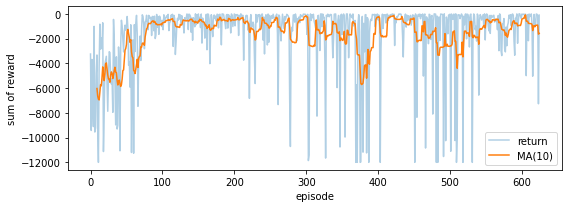

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(episode_returns, alpha=0.35, label="return")
if len(episode_returns) >= 10:
    win = 10
    smoothed = np.convolve(episode_returns, np.ones(win) / win, mode="valid")
    plt.plot(range(win - 1, len(episode_returns)), smoothed, label=f"MA({win})")
plt.xlabel("episode"); plt.ylabel("sum of reward"); plt.legend(); plt.tight_layout(); plt.show()

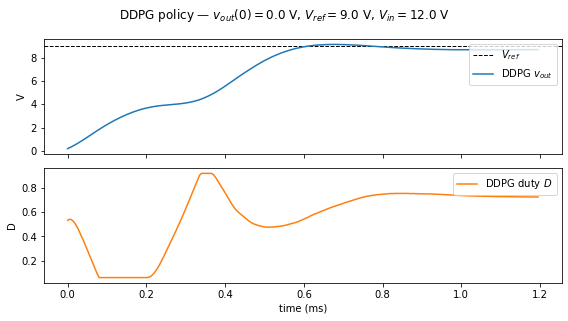

In [5]:
def rollout_deterministic(
    env: BuckAvgEnvContinuous,
    actor: Actor,
    v_ref: float,
    v0: float,
    vin: Optional[float] = None,
    i0: Optional[float] = None,
    D0: Optional[float] = None,
    seed: int = 999,
):
    # Greedy DDPG rollout (no exploration noise)
    np.random.seed(seed)
    random.seed(seed)
    if vin is not None:
        env.Vin = float(np.clip(vin, env.vin_min, env.vin_max))
        env._rescale_for_vin()
    env.v_ref = float(v_ref)
    v0 = float(np.clip(v0, 0.01 * env.Vin, 0.99 * env.Vin))
    if i0 is None:
        i0 = float(np.random.uniform(0.0, env.i_scale * 0.5))
    else:
        i0 = float(np.clip(i0, 0.0, env.i_scale))
    if D0 is None:
        D0 = float(np.random.uniform(env.d_min, env.d_max))
    else:
        D0 = float(np.clip(D0, env.d_min, env.d_max))
    env.state = np.array([i0, v0, D0], dtype=np.float64)
    env.step_count = 0
    obs = env._observe()

    log = {"v": [], "d": [], "iL": []}
    for _ in range(env.max_episode_steps):
        with torch.no_grad():
            u = actor(torch.tensor(obs, device=device, dtype=torch.float32).unsqueeze(0))
        u = float(torch.clamp(u, -1.0, 1.0).item())
        obs, _, term, trunc, _ = env.step(u)
        iL, v, D = env.state
        log["v"].append(v)
        log["d"].append(D)
        log["iL"].append(iL)
        if term or trunc:
            break
    return log

eval_env = BuckAvgEnvContinuous()
target_v = 9.0
v_init = 0.0
trace = rollout_deterministic(eval_env, actor_net, v_ref=target_v, v0=v_init, vin=12.0, seed=999)

t_axis = np.arange(len(trace["v"])) * eval_env.dt * 1e3

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
ax[0].axhline(target_v, color="k", ls="--", lw=1, label=r"$V_{ref}$")
ax[0].plot(t_axis, trace["v"], label=r"DDPG $v_{out}$")
ax[0].set_ylabel("V")
ax[0].legend(loc="upper right")
ax[1].plot(t_axis, trace["d"], color="C1", label=r"DDPG duty $D$")
ax[1].set_ylabel("D")
ax[1].set_xlabel("time (ms)")
ax[1].legend(loc="upper right")
plt.suptitle(
    rf"DDPG policy — $v_{{out}}(0)={v_init}$ V, $V_{{ref}}={target_v}$ V, $V_{{in}}={eval_env.Vin:.1f}$ V"
)
plt.tight_layout()
plt.show()


## Alternate reward: smooth duty (actuation penalty)

The baseline reward emphasizes **output voltage tracking** ($-e_v^2$) plus a small inductor-current regularizer. Another practical objective is **smooth duty command**: large steps in $D$ can stress the gate driver and widen spectra. Here we add a **moderate** penalty proportional to $(\Delta D)^2$, normalized by the admissible duty range $(D_{max}-D_{min})$. The plant dynamics are unchanged—only the **reward** changes.

We train a second **DDPG** actor on `BuckAvgEnvSmoothDuty` (continuous action), with `duty_step_penalty` set slightly above the first reference value so the effect is visible without preventing learning.

In [6]:
class BuckAvgEnvSmoothDuty(BuckAvgEnvContinuous):
    # Continuous action; adds penalty on per-step (Delta D)^2 for smooth duty.

    def __init__(self, duty_step_penalty: float = 150.0, **kwargs):
        super().__init__(**kwargs)
        self.duty_step_penalty = float(duty_step_penalty)

    def step(self, action: float):
        u = float(np.clip(action, -1.0, 1.0))
        iL, v, D_prev = self.state
        D = float(np.clip(D_prev + u * self.delta_d_max, self.d_min, self.d_max))

        di = (D * self.Vin - v) / self.L
        dv = (iL - v / self.R) / self.C
        noise = np.random.randn(2) * np.array(
            [self.i_scale * 2e-4, self.v_scale * 1e-4]
        )
        iL = iL + self.dt * di + noise[0]
        v = v + self.dt * dv + noise[1]
        iL = float(np.clip(iL, 0.0, self.i_scale))
        v = float(np.clip(v, 0.0, self.Vin))
        self.state = np.array([iL, v, D], dtype=np.float64)
        self.step_count += 1

        err = v - self.v_ref
        d_span = max(self.d_max - self.d_min, 1e-6)
        d_step_norm = (D - D_prev) / d_span
        r_track = -float(err**2)
        r_smooth = -self.duty_step_penalty * float(d_step_norm**2)
        r_i = -1e-4 * (iL / max(self.i_scale, 1e-6)) ** 2
        reward = float(np.clip(r_track + r_smooth + r_i, -50.0, 0.0))

        terminated = bool(v < 0.02 * self.v_ref or v > 1.08 * self.Vin)
        truncated = self.step_count >= self.max_episode_steps
        return self._observe(), reward, terminated, truncated, {}


train_env_smooth = BuckAvgEnvSmoothDuty(duty_step_penalty=150.0)
actor_smooth, episode_returns_smooth, _ = train_ddpg(
    train_env_smooth, total_steps=150_000, seed=42
)
print("smooth-duty reward: trained episodes:", len(episode_returns_smooth))


step 500  buf=500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.249  Vin=20.80  v_ref=6.95  v=12.634  D=0.143  ep_ret(last)=-7050.6
step 1000  buf=1000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.249  Vin=13.08  v_ref=9.09  v=11.193  D=0.784  ep_ret(last)=-2285.5
step 1500  buf=1500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.248  Vin=16.73  v_ref=4.93  v=6.930  D=0.547  ep_ret(last)=-6286.8
step 2000  buf=2000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.247  Vin=19.31  v_ref=14.42  v=13.515  D=0.920  ep_ret(last)=-1567.6
step 2500  buf=2500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.247  Vin=23.13  v_ref=10.83  v=17.109  D=0.119  ep_ret(last)=-7114.2
step 3000  buf=3000  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.246  Vin=12.28  v_ref=8.97  v=11.683  D=0.749  ep_ret(last)=-2943.4
step 3500  buf=3500  c_loss=nan  a_obj=nan  Q_mean=nan  ou_sigma=0.245  Vin=10.68  v_ref=8.20  v=10.532  D=0.756  ep_ret(last)=-1185.2
step 4000  buf=4000  c_loss=nan  a_obj=nan  Q_mean=nan  

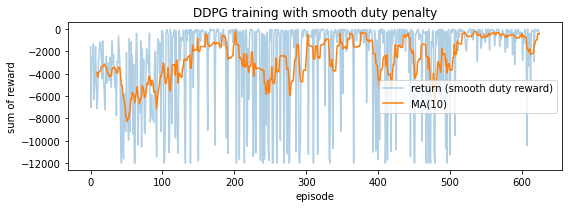

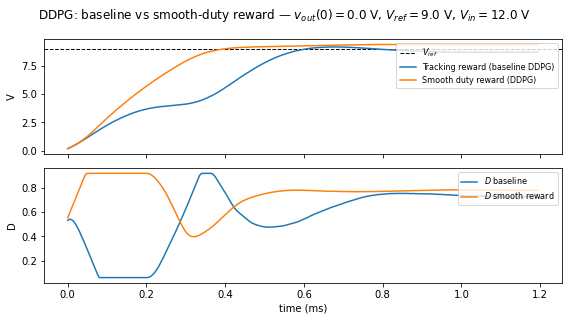

In [7]:
plt.figure(figsize=(8, 3))
plt.plot(episode_returns_smooth, alpha=0.35, label="return (smooth duty reward)")
if len(episode_returns_smooth) >= 10:
    win = 10
    smoothed_s = np.convolve(episode_returns_smooth, np.ones(win) / win, mode="valid")
    plt.plot(range(win - 1, len(episode_returns_smooth)), smoothed_s, label=f"MA({win})")
plt.xlabel("episode")
plt.ylabel("sum of reward")
plt.title("DDPG training with smooth duty penalty")
plt.legend()
plt.tight_layout()
plt.show()

eval_track = BuckAvgEnvContinuous()
eval_smooth = BuckAvgEnvSmoothDuty(duty_step_penalty=150.0)
target_v = 9.0
v_init = 0.0
vin_fixed = 12.0
roll_seed = 999

trace_track = rollout_deterministic(
    eval_track, actor_net, v_ref=target_v, v0=v_init, vin=vin_fixed, seed=roll_seed
)
trace_smooth = rollout_deterministic(
    eval_smooth, actor_smooth, v_ref=target_v, v0=v_init, vin=vin_fixed, seed=roll_seed
)

t_track = np.arange(len(trace_track["v"])) * eval_track.dt * 1e3
t_smooth = np.arange(len(trace_smooth["v"])) * eval_smooth.dt * 1e3

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
ax[0].axhline(target_v, color="k", ls="--", lw=1, label=r"$V_{ref}$")
ax[0].plot(t_track, trace_track["v"], label=r"Tracking reward (baseline DDPG)")
ax[0].plot(t_smooth, trace_smooth["v"], label=r"Smooth duty reward (DDPG)")
ax[0].set_ylabel("V")
ax[0].legend(loc="upper right", fontsize=8)
ax[1].plot(t_track, trace_track["d"], label=r"$D$ baseline")
ax[1].plot(t_smooth, trace_smooth["d"], label=r"$D$ smooth reward")
ax[1].set_ylabel("D")
ax[1].set_xlabel("time (ms)")
ax[1].legend(loc="upper right", fontsize=8)
plt.suptitle(
    rf"DDPG: baseline vs smooth-duty reward — $v_{{out}}(0)={v_init}$ V, $V_{{ref}}={target_v}$ V, $V_{{in}}={vin_fixed}$ V"
)
plt.tight_layout()
plt.show()
